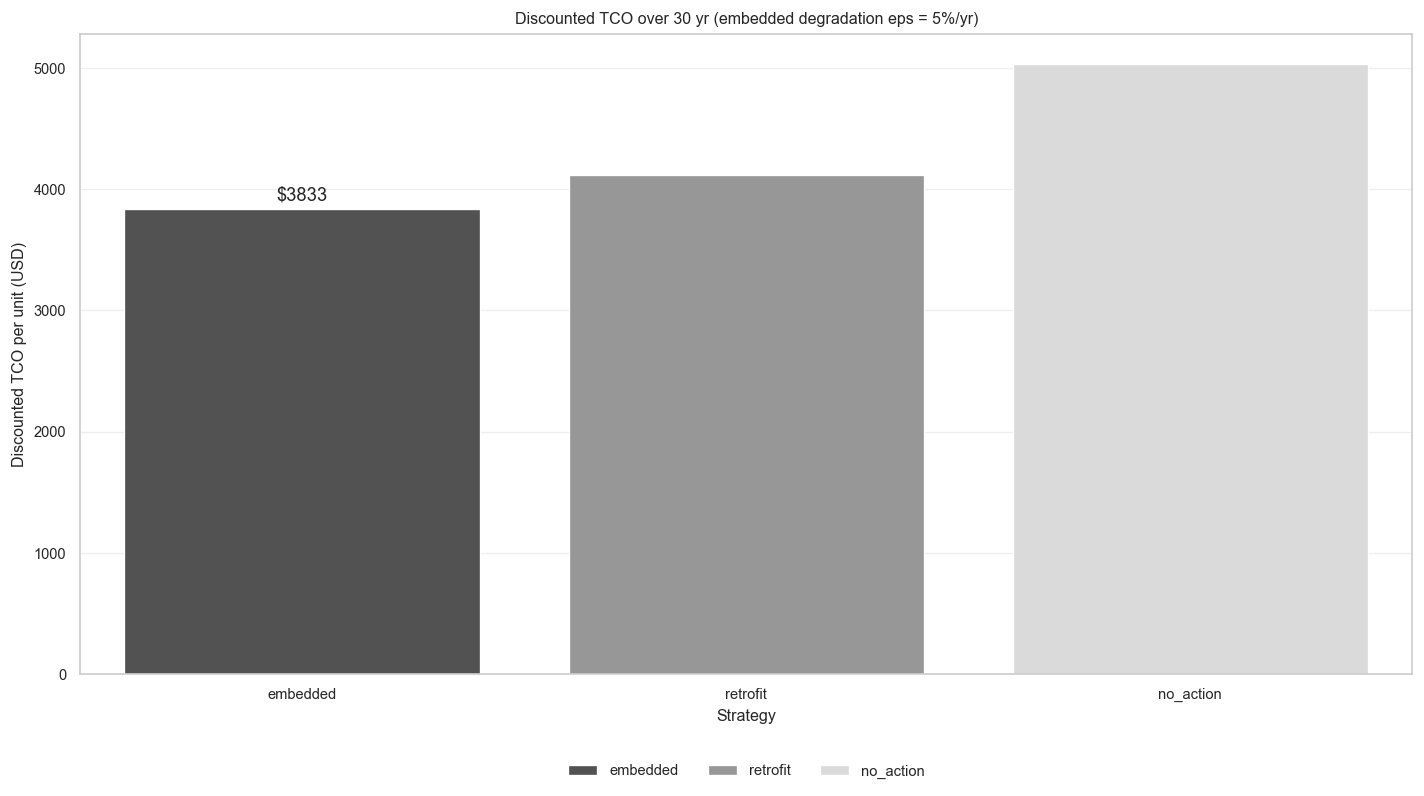

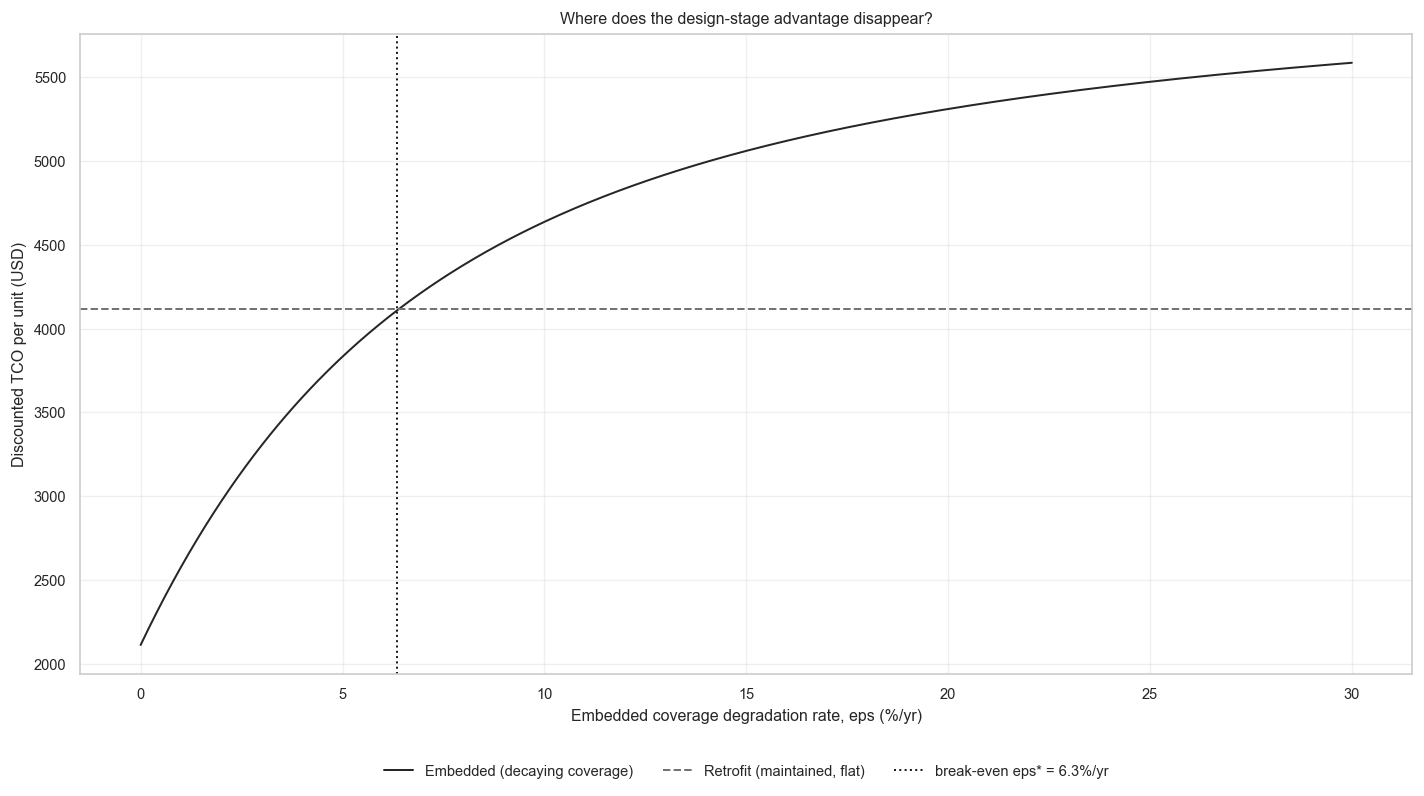

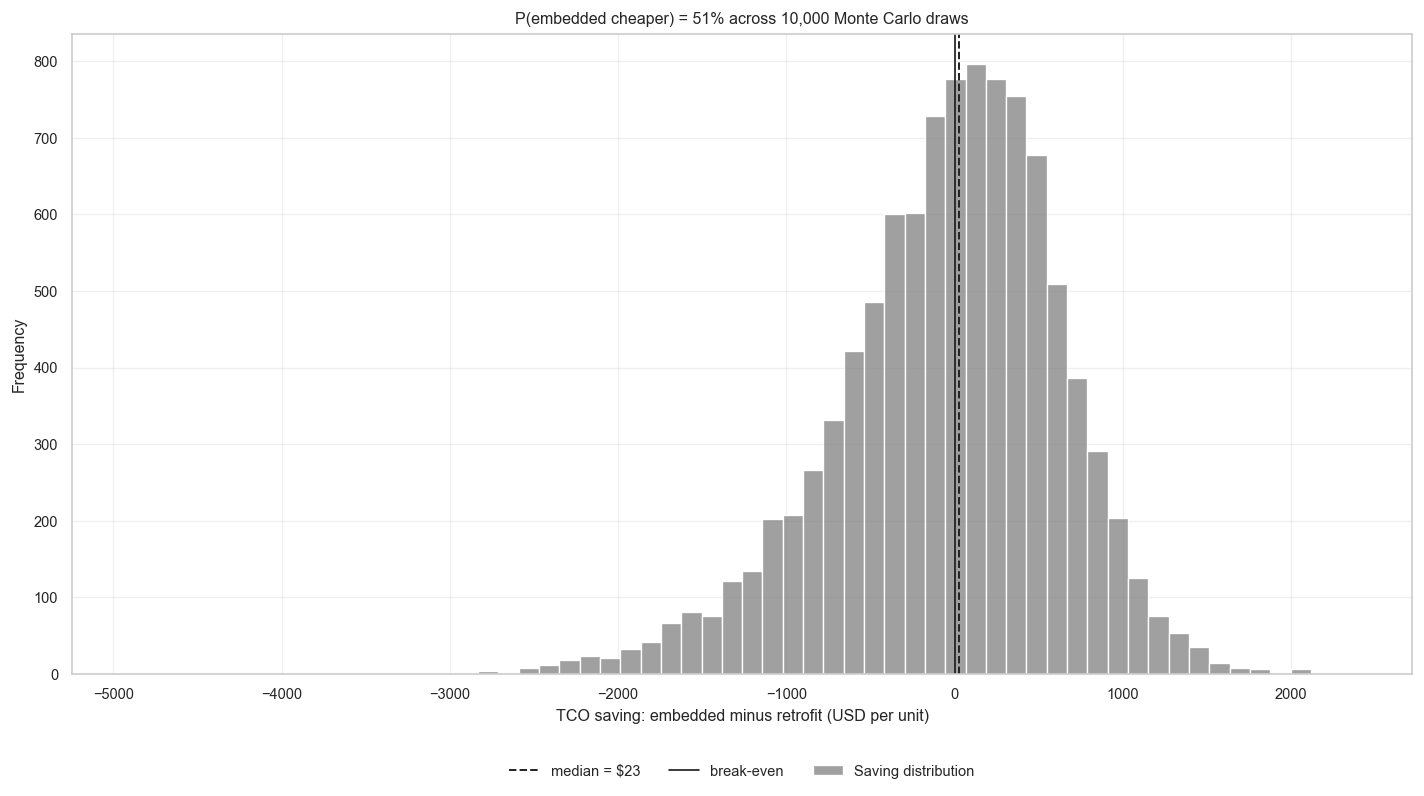

In [1]:
# ============================================================
# 01_cost_benefit_simulation.ipynb  (script form)
# Cell 1 — Imports, paths, and global configuration
# ============================================================
# Purpose: set up the analysis environment, define reproducible
# input/output paths, and fix the random seed so that every run
# of this notebook produces identical figures and tables.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility: a fixed seed keeps the Monte Carlo sensitivity
# analysis (Cell 6) identical across runs.
RNG = np.random.default_rng(seed=42)

# Project paths. This notebook lives in leak-iot-study/notebooks/,
# so data and results are one level up.
BASE_DIR    = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR    = BASE_DIR / "data"
FIG_DIR     = BASE_DIR / "results" / "figures"
TABLE_DIR   = BASE_DIR / "results" / "tables"

for d in (FIG_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Global figure style: seaborn, grayscale, 16:9, high-resolution export.
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette("Greys")
plt.rcParams.update({
    "figure.dpi": 120,      # on-screen preview
    "savefig.dpi": 600,     # exported files
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
FIGSIZE = (12, 6.75)        # 16:9 aspect ratio

def save_fig(fig, stem: str):
    """Save a figure to results/figures/ as both PNG and PDF at 600 dpi."""
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", dpi=600, bbox_inches="tight")


# ============================================================
# Cell 2 — Load the parameter table (primary-source values)
# ============================================================
# Purpose: load data/parameters.csv, which stores every numeric
# input together with its unit and primary-source citation. Keeping
# citations in the data file (not hard-coded here) preserves the
# audit trail required for a reproducible, review-ready paper.

params = pd.read_csv(DATA_DIR / "parameters.csv")

def get_param(param_id: str) -> float:
    """Return the numeric value of a parameter by its param_id."""
    row = params.loc[params["param_id"] == param_id, "value"]
    if row.empty:
        raise KeyError(f"param_id not found: {param_id}")
    return float(row.iloc[0])

params[["param_id", "parameter", "value", "unit", "source_citation"]]


# ============================================================
# Cell 3 — Scenario assumptions (EVIDENCE-GROUNDED)
# ============================================================
# Purpose: define the three strategies with parameters derived from
# the cited literature in data/parameters.csv, rather than arbitrary
# placeholders. Each derived value notes its source param_id.
#
# --- The trade-off that makes this comparison non-trivial ---
# Earlier drafts made the embedded strategy strictly dominate the
# retrofit strategy on BOTH install cost AND effectiveness, so the
# Monte Carlo returned P(embedded cheaper) = 1.0 — an artefact of the
# assumptions, not a finding. We remove that artefact by modelling the
# one structural DISADVANTAGE of embedding: sensors cast into the pipe
# at construction cannot be accessed, serviced, or replaced. Their
# effective coverage therefore DEGRADES over the asset life at an
# annual rate epsilon (sensor drift, fouling, dead nodes, battery/energy
# loss with no maintenance access). Retrofit sensors are accessible and
# are assumed maintained, so their coverage stays flat.
#
#   embedded : low install cost, high INITIAL coverage, but DECAYING
#   retrofit : high install cost, lower coverage, but MAINTAINED (flat)
#
# The winner now depends on epsilon and the horizon. This is the honest
# trade-off, and Cell 6-7 quantify where it tips.
#
# Effectiveness anchor: a controlled loss-correlation study (p21,
# LexisNexis 2020) found a 96% reduction in escape-of-water claim
# frequency for homes with smart shutoff. This is an INDUSTRY (non
# peer-reviewed) figure and a DIFFERENT device class (whole-home
# shutoff, not embedded pipe sensing); we therefore use it only as an
# upper-bound effectiveness anchor, derate it heavily by coverage, and
# stress-test every derived quantity in Cell 6. State this clearly in
# the paper's limitations.

HORIZON_YEARS = 30          # asset life cycle considered
DISCOUNT_RATE = 0.03        # annual discount rate for NPV

# --- Baseline annual water-damage loss per unit (no detection) ---
# p06: average claim USD 15,400; p07: ~1 in 60 homes/yr incident rate.
ANNUAL_INCIDENT_PROB = get_param("p07")     # p07  (0.01667 = 1/60)
CLAIM_COST           = get_param("p06")     # p06
BASELINE_ANNUAL_LOSS = ANNUAL_INCIDENT_PROB * CLAIM_COST

# --- Effectiveness (fraction of baseline loss avoided) ---
# p21: 96% frequency reduction under ideal, fully-covered conditions.
# Coverage derates below are MODELLING ASSUMPTIONS (state them as such
# in the paper); vary them in the Cell 6 sensitivity analysis.
FREQ_REDUCTION_IDEAL = get_param("p21") / 100.0   # p21 = 96% -> 0.96
COVERAGE_EMBEDDED_0  = 0.85   # design-stage INITIAL coverage (year 1)
COVERAGE_RETROFIT    = 0.60   # post-hoc coverage, held flat by servicing
EFF_EMBEDDED_0 = FREQ_REDUCTION_IDEAL * COVERAGE_EMBEDDED_0   # ~0.816 (year 1)
EFF_RETROFIT   = FREQ_REDUCTION_IDEAL * COVERAGE_RETROFIT     # ~0.576 (flat)

# --- Degradation rate of embedded coverage (NEW; key assumption) ---
# Un-replaceable embedded sensors lose effective coverage each year.
# No direct primary source exists; treated as an explicit modelling
# assumption and the primary object of the break-even analysis (Cell 7).
DEGRADATION_RATE_EMBEDDED = 0.05   # eps: 5%/yr point assumption

# --- Install cost (USD per unit) ---
# Anchored to a nominal embedded cost, with retrofit scaled up by the
# access-driven premium. p20 (wireless vs wired labor ~4x) and general
# retrofit-premium evidence (p17-p19) motivate a retrofit multiplier > 1.
INSTALL_EMBEDDED    = 600.0                 # nominal design-stage install
RETROFIT_MULTIPLIER = 2.0                   # access/labor premium (see p17-p20)
INSTALL_RETROFIT    = INSTALL_EMBEDDED * RETROFIT_MULTIPLIER

# --- Annual O&M (USD per unit) ---
OM_EMBEDDED = 30.0
OM_RETROFIT = 40.0


# ============================================================
# Cell 4 — Life-cycle cost model (TCO via discounted cash flow)
# ============================================================
# Purpose: compute the total cost of ownership (TCO) for each strategy
# as the net present value of install cost + annual O&M + residual
# (non-avoided) water-damage loss over the asset horizon.
#
# Two effectiveness profiles:
#   * FLAT   (retrofit, no_action): effectiveness constant each year.
#   * DECAY  (embedded): effectiveness = eff0 * (1 - eps)^(t-1), so the
#            residual loss grows year on year as un-serviced sensors fail.

def discounted_tco_flat(install_cost, annual_om, loss_avoided,
                        baseline_loss=BASELINE_ANNUAL_LOSS,
                        horizon=HORIZON_YEARS, rate=DISCOUNT_RATE):
    """Discounted TCO for a strategy with constant effectiveness."""
    residual_loss = baseline_loss * (1.0 - loss_avoided)
    annual_flow   = annual_om + residual_loss
    years         = np.arange(1, horizon + 1)
    discount      = 1.0 / (1.0 + rate) ** years
    return install_cost + np.sum(annual_flow * discount)

def discounted_tco_decay(install_cost, annual_om, loss_avoided_0, eps,
                         baseline_loss=BASELINE_ANNUAL_LOSS,
                         horizon=HORIZON_YEARS, rate=DISCOUNT_RATE):
    """Discounted TCO for embedded sensors whose coverage decays at eps/yr."""
    years         = np.arange(1, horizon + 1)
    eff_t         = loss_avoided_0 * (1.0 - eps) ** (years - 1)   # year 1 = eff0
    residual_t    = baseline_loss * (1.0 - eff_t)                 # grows over time
    annual_flow   = annual_om + residual_t
    discount      = 1.0 / (1.0 + rate) ** years
    return install_cost + np.sum(annual_flow * discount)

rows = [
    dict(strategy="no_action",
         tco_usd=discounted_tco_flat(0.0, 0.0, 0.0),
         install=0.0, loss_avoided_y1=0.0),
    dict(strategy="retrofit",
         tco_usd=discounted_tco_flat(INSTALL_RETROFIT, OM_RETROFIT, EFF_RETROFIT),
         install=INSTALL_RETROFIT, loss_avoided_y1=EFF_RETROFIT),
    dict(strategy="embedded",
         tco_usd=discounted_tco_decay(INSTALL_EMBEDDED, OM_EMBEDDED,
                                      EFF_EMBEDDED_0, DEGRADATION_RATE_EMBEDDED),
         install=INSTALL_EMBEDDED, loss_avoided_y1=EFF_EMBEDDED_0),
]
tco_df = pd.DataFrame(rows).sort_values("tco_usd").reset_index(drop=True)
tco_df["tco_usd"] = tco_df["tco_usd"].round(2)

baseline_tco = tco_df.loc[tco_df["strategy"] == "no_action", "tco_usd"].iloc[0]
tco_df["savings_vs_no_action"] = (baseline_tco - tco_df["tco_usd"]).round(2)
tco_df


# ============================================================
# Cell 5 — Figure: TCO comparison across strategies
# ============================================================
# Purpose: visualise discounted TCO by strategy (seaborn, grayscale,
# 16:9) and save to results/figures/ as PNG + PDF at 600 dpi.
# The legend is placed below the axes so it never overlaps the bars.

fig, ax = plt.subplots(figsize=FIGSIZE)
order = tco_df.sort_values("tco_usd")
sns.barplot(data=order, x="strategy", y="tco_usd",
            hue="strategy", palette="Greys_r", legend=True, ax=ax)
ax.set_ylabel("Discounted TCO per unit (USD)")
ax.set_xlabel("Strategy")
ax.bar_label(ax.containers[0], fmt="$%.0f", padding=3)
sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, -0.12),
                ncol=3, frameon=False, title=None)
ax.set_title(f"Discounted TCO over {HORIZON_YEARS} yr "
             f"(embedded degradation eps = {DEGRADATION_RATE_EMBEDDED:.0%}/yr)")
fig.tight_layout()
save_fig(fig, "fig01_tco_comparison")
plt.show()


# ============================================================
# Cell 6 — Sensitivity analysis (Monte Carlo)
# ============================================================
# Purpose: TCO depends on uncertain inputs (incident probability,
# claim cost, coverage-derated effectiveness, and — critically — the
# embedded degradation rate eps). We draw N random samples and report
# the distribution of the embedded-vs-retrofit saving. Because embedding
# now carries a genuine downside (irreversible coverage decay), the
# probability that embedding wins is an informative output, NOT a
# foregone conclusion.

N = 10_000
years   = np.arange(1, HORIZON_YEARS + 1)
disc    = 1.0 / (1.0 + DISCOUNT_RATE) ** years

# Uncertain inputs (triangular / normal around point assumptions).
incident_prob = RNG.triangular(1/120, 1/60, 1/30, size=N)
claim_cost    = np.clip(RNG.normal(CLAIM_COST, CLAIM_COST * 0.20, N), 1_000, None)
base_loss     = incident_prob * claim_cost                      # (N,)

cov_embedded0 = RNG.triangular(0.75, 0.85, 0.95, size=N)        # embedded initial
cov_retrofit  = RNG.triangular(0.45, 0.60, 0.75, size=N)        # retrofit (flat)
eps_embedded  = RNG.triangular(0.02, 0.05, 0.12, size=N)        # NEW: decay rate

eff_embedded0 = FREQ_REDUCTION_IDEAL * cov_embedded0
eff_retrofit  = FREQ_REDUCTION_IDEAL * cov_retrofit

# Retrofit: flat effectiveness -> closed form over the annuity.
tco_retrofit = (INSTALL_RETROFIT
                + np.sum((OM_RETROFIT
                          + base_loss[:, None] * (1.0 - eff_retrofit[:, None]))
                         * disc, axis=1))

# Embedded: decaying effectiveness -> full (N, HORIZON) evaluation.
eff_emb_t   = eff_embedded0[:, None] * (1.0 - eps_embedded[:, None]) ** (years - 1)
resid_emb_t = base_loss[:, None] * (1.0 - eff_emb_t)
tco_embedded = INSTALL_EMBEDDED + np.sum((OM_EMBEDDED + resid_emb_t) * disc, axis=1)

saving = tco_retrofit - tco_embedded   # positive => embedded is cheaper

summary = pd.Series({
    "mean_saving_usd":       saving.mean(),
    "median_saving_usd":     np.median(saving),
    "p05_saving_usd":        np.percentile(saving, 5),
    "p95_saving_usd":        np.percentile(saving, 95),
    "prob_embedded_cheaper": (saving > 0).mean(),
}).round(2)
summary


# ============================================================
# Cell 7 — Break-even analysis on the degradation rate
# ============================================================
# Purpose: the central modelling assumption is eps, the annual rate at
# which un-serviceable embedded coverage decays. Here we hold all other
# inputs at their point values and sweep eps to find eps*, the rate at
# which embedded and retrofit TCO are equal. Below eps* embedding wins;
# above it, the accessibility of retrofit sensors pays for their higher
# install cost. Reporting eps* makes the conclusion's dependence on the
# key assumption explicit and auditable.

eps_grid = np.linspace(0.0, 0.30, 601)
tco_ret_point = discounted_tco_flat(INSTALL_RETROFIT, OM_RETROFIT, EFF_RETROFIT)
tco_emb_curve = np.array([
    discounted_tco_decay(INSTALL_EMBEDDED, OM_EMBEDDED, EFF_EMBEDDED_0, e)
    for e in eps_grid
])

diff = tco_ret_point - tco_emb_curve            # >0 => embedded cheaper
# eps* = first grid point where the sign flips
sign_change = np.where(np.diff(np.sign(diff)))[0]
eps_star = eps_grid[sign_change[0]] if sign_change.size else np.nan

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(eps_grid * 100, tco_emb_curve, color="0.15",
        label="Embedded (decaying coverage)")
ax.axhline(tco_ret_point, linestyle="--", color="0.45",
           label="Retrofit (maintained, flat)")
if np.isfinite(eps_star):
    ax.axvline(eps_star * 100, linestyle=":", color="k",
               label=f"break-even eps* = {eps_star:.1%}/yr")
ax.set_xlabel("Embedded coverage degradation rate, eps (%/yr)")
ax.set_ylabel("Discounted TCO per unit (USD)")
ax.set_title("Where does the design-stage advantage disappear?")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
fig.tight_layout()
save_fig(fig, "fig03_breakeven_degradation")
plt.show()


# ============================================================
# Cell 8 — Figure: distribution of embedded-vs-retrofit saving
# ============================================================
# Purpose: plot the Monte Carlo distribution of the per-unit saving
# from embedding rather than retrofitting (seaborn, grayscale, 16:9),
# mark the median and break-even, and save as PNG + PDF at 600 dpi.
# The legend sits below the axes to avoid overlapping the histogram.

fig, ax = plt.subplots(figsize=FIGSIZE)
sns.histplot(saving, bins=60, ax=ax, color="0.5", label="Saving distribution")
ax.axvline(np.median(saving), linestyle="--", color="0.15",
           label=f"median = ${np.median(saving):,.0f}")
ax.axvline(0, color="k", linewidth=1, label="break-even")
ax.set_xlabel("TCO saving: embedded minus retrofit (USD per unit)")
ax.set_ylabel("Frequency")
ax.set_title(f"P(embedded cheaper) = {(saving > 0).mean():.0%} "
             f"across {N:,} Monte Carlo draws")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
fig.tight_layout()
save_fig(fig, "fig02_sensitivity_saving")
plt.show()


# ============================================================
# Cell 9 — Export result tables
# ============================================================
# Purpose: write the TCO comparison, the sensitivity summary, and the
# break-even value to results/tables/ as CSV files for the manuscript
# and for archival reproducibility.

tco_df.to_csv(TABLE_DIR / "table01_tco_by_strategy.csv", index=False)
summary.to_frame(name="value").to_csv(TABLE_DIR / "table02_sensitivity_summary.csv")
pd.Series({"eps_star_breakeven": eps_star}).to_frame("value").to_csv(
    TABLE_DIR / "table03_breakeven.csv")
